In [22]:
import numpy as np
import pandas as pd
import missingno
pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [23]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

In [24]:
NUTS2 = 'Thessaly'
YEAR = '2024'

In [25]:
data = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)

In [26]:
try:
    data.drop(columns=['Unnamed: 0'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

In [27]:
try:
    data.drop(columns=['Unnamed: 0.1'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

No column named 'Unnamed: 0'


<Axes: >

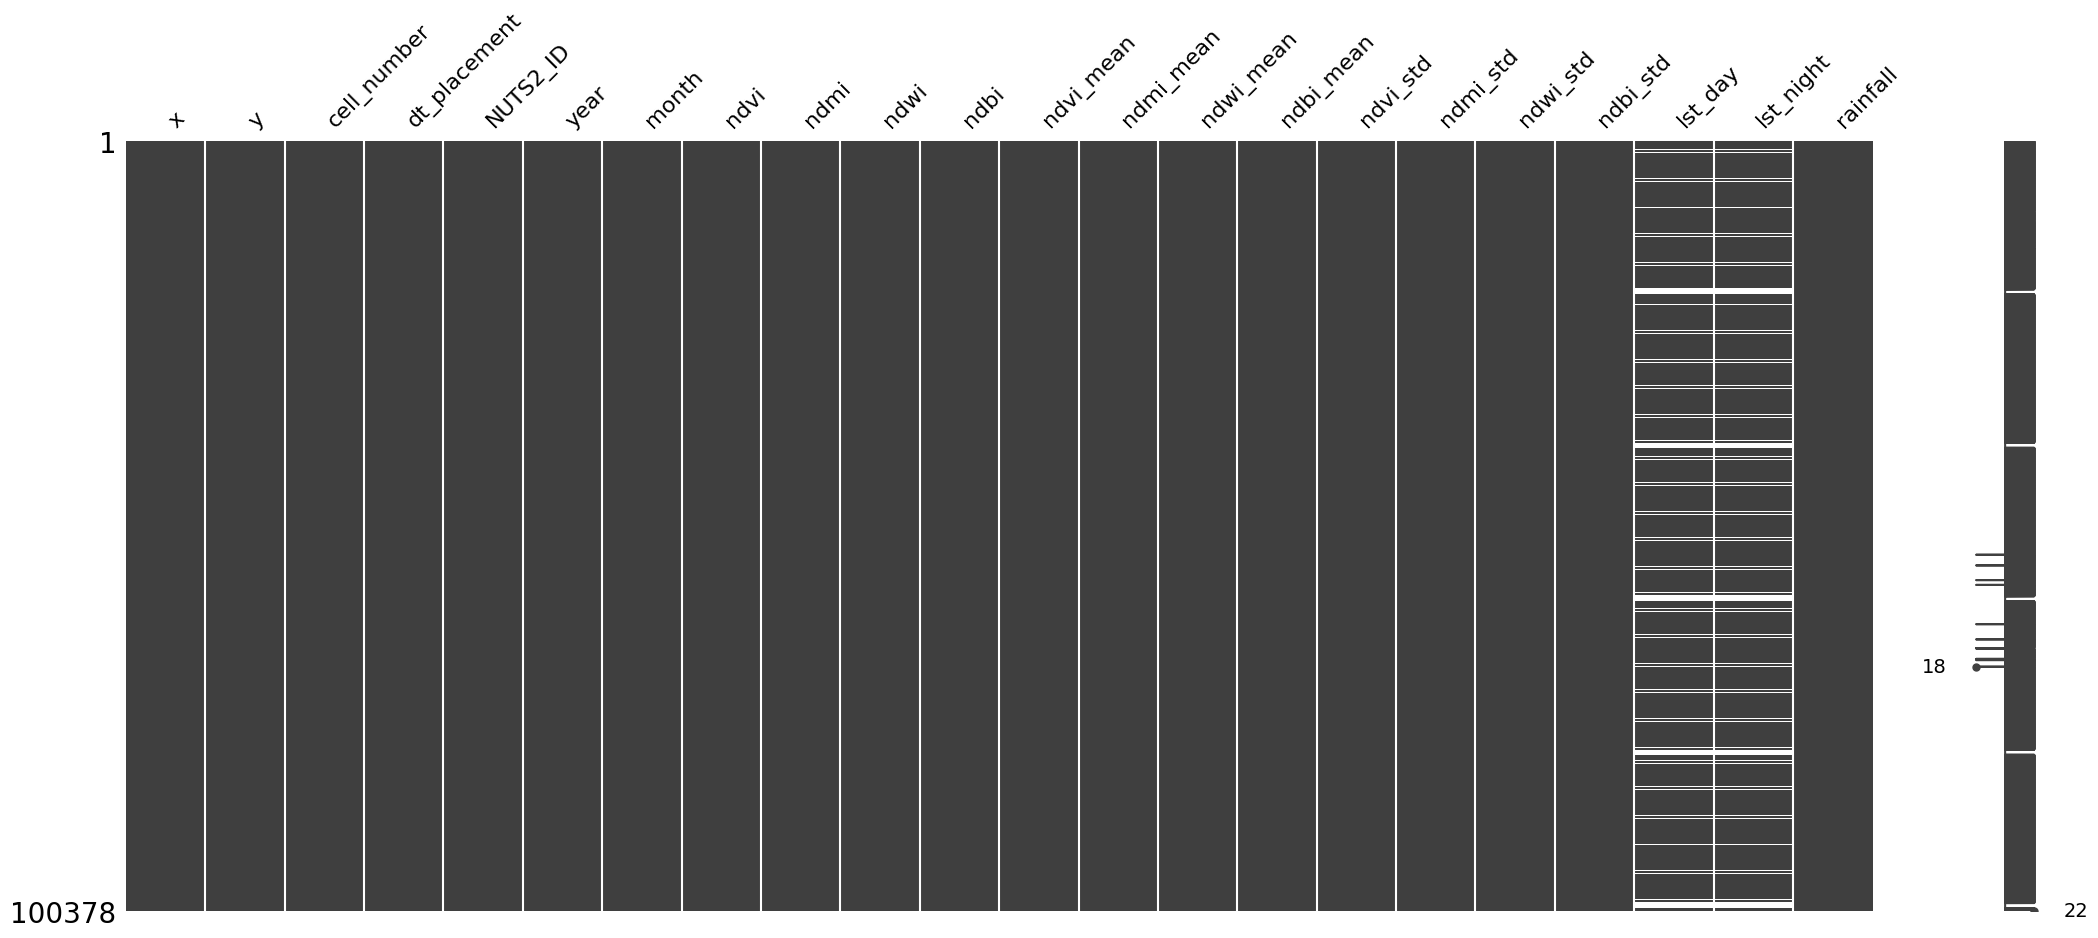

In [28]:
missingno.matrix(data)

In [29]:
data.dtypes

x               float64
y               float64
cell_number       int64
dt_placement     object
NUTS2_ID         object
year              int64
month             int64
ndvi            float64
ndmi            float64
ndwi            float64
ndbi            float64
ndvi_mean       float64
ndmi_mean       float64
ndwi_mean       float64
ndbi_mean       float64
ndvi_std        float64
ndmi_std        float64
ndwi_std        float64
ndbi_std        float64
lst_day         float64
lst_night       float64
rainfall        float64
dtype: object

<Axes: >

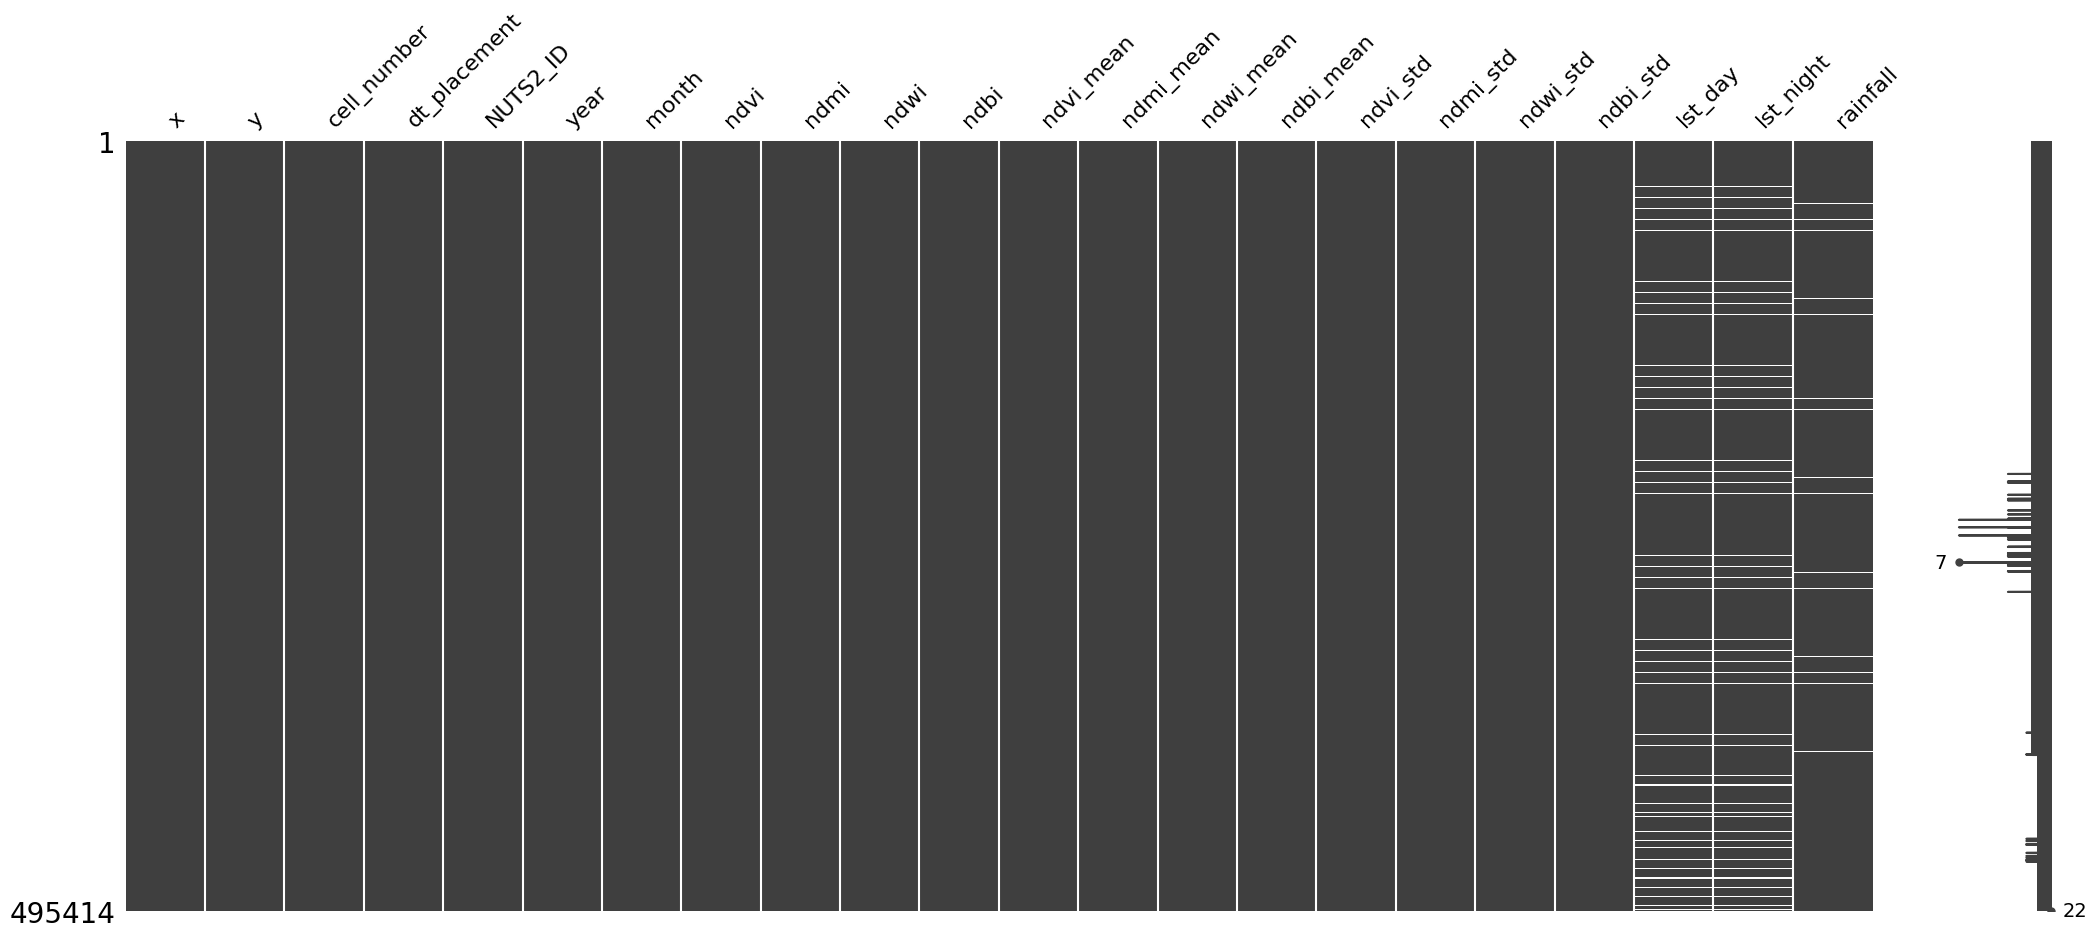

In [30]:
data_old = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled_shp.csv', encoding=enc)
data_old_subset = data_old[data.columns]

data = pd.concat([data_old_subset, data], axis=0, ignore_index=True)
missingno.matrix(data)

In [31]:
# data.lst_day.unique()

In [32]:
# data['lst_day'] = data['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [33]:
# data['lst_day'] = data['lst_day'].astype(float)

In [34]:
# data.drop(columns=['rainfall.1'], inplace=True)

In [35]:
data['dt_placement'] = pd.to_datetime(data['dt_placement'])

# Extract year, month, and day from the 'date' column
data['year'] = data['dt_placement'].dt.year
data['month'] = data['dt_placement'].dt.month
data['day'] = data['dt_placement'].dt.day

In [36]:
data

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day
0,21.15549,39.67943,0,2024-01-01,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.0,13651.0,1.164514,1
1,21.15549,39.67943,0,2024-01-02,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.0,13651.0,11.846938,2
2,21.15549,39.67943,0,2024-01-03,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.0,13651.0,0.714449,3
3,21.15549,39.67943,0,2024-01-04,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.0,13724.0,0.000000,4
4,21.15549,39.67943,0,2024-01-05,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13863.0,13643.0,0.250432,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495409,23.74369,39.10450,3233,2024-06-01,EL61,2024,6,0.568739,0.237624,-0.489304,-0.237624,0.587479,0.291392,-0.491882,-0.291392,0.071258,0.074697,0.041490,0.074697,NaN,NaN,0.000000,1
495410,23.90545,39.19433,3234,2024-06-01,EL61,2024,6,0.528387,0.153079,-0.454713,-0.153079,0.545313,0.171863,-0.468413,-0.171863,0.046762,0.048031,0.027824,0.048031,NaN,NaN,0.000000,1
495411,23.90545,39.21230,3235,2024-06-01,EL61,2024,6,0.529784,0.094728,-0.462851,-0.094728,0.483191,0.138257,-0.406922,-0.138257,0.017340,0.013679,0.022010,0.013679,NaN,NaN,0.000000,1
495412,23.92856,39.23027,3236,2024-06-01,EL61,2024,6,0.636646,0.251187,-0.517857,-0.251187,0.553087,0.185421,-0.475038,-0.185421,0.052659,0.051064,0.029595,0.051064,NaN,NaN,0.000000,1


In [37]:
data_jan = data.loc[data['month'] == 1]
data_fed = data.loc[data['month'] == 2]
data_mar = data.loc[data['month'] == 3]
data_apr = data.loc[data['month'] == 4]

In [38]:
df_mean_jan = data_jan.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_feb = data_fed.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_mar = data_mar.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_apr = data_apr.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()

In [39]:
df_mean_jan.rename(columns={'lst_day': 'lst_day_jan_mean', 'lst_night': 'lst_night_jan_mean'}, inplace=True)
df_mean_feb.rename(columns={'lst_day': 'lst_day_feb_mean', 'lst_night': 'lst_night_feb_mean'}, inplace=True)
df_mean_mar.rename(columns={'lst_day': 'lst_day_mar_mean', 'lst_night': 'lst_night_mar_mean'}, inplace=True)
df_mean_apr.rename(columns={'lst_day': 'lst_day_apr_mean', 'lst_night': 'lst_night_apr_mean'}, inplace=True)

In [40]:
df_mean_jan.drop(columns=['month'], inplace = True)
df_mean_feb.drop(columns=['month'], inplace = True)
df_mean_mar.drop(columns=['month'], inplace = True)
df_mean_apr.drop(columns=['month'], inplace = True)

In [41]:
df_mean = pd.merge(df_mean_jan, df_mean_feb, on=['cell_number', 'year']).merge(df_mean_mar, on=['cell_number', 'year']).merge(df_mean_apr, on=['cell_number', 'year'])

In [42]:
df_mean.loc[(df_mean['cell_number'] == 0) & (df_mean['year'] == int(YEAR))]

,cell_number,year,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,0,2024,13607.903226,13633.967742,13652.862069,13682.965517,13892.0,13649.096774,14751.6,13889.96


In [43]:
data_mean = pd.merge(data, df_mean, on=['cell_number', 'year'])

In [44]:
data_mean

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,21.15549,39.67943,0,2024-01-01,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.0,13651.0,1.164514,1,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.60,13889.96
1,21.15549,39.67943,0,2024-01-02,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.0,13651.0,11.846938,2,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.60,13889.96
2,21.15549,39.67943,0,2024-01-03,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.0,13651.0,0.714449,3,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.60,13889.96
3,21.15549,39.67943,0,2024-01-04,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.0,13724.0,0.000000,4,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.60,13889.96
4,21.15549,39.67943,0,2024-01-05,EL61,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13863.0,13643.0,0.250432,5,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.60,13889.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495409,23.74369,39.10450,3233,2024-06-01,EL61,2024,6,0.568739,0.237624,-0.489304,-0.237624,0.587479,0.291392,-0.491882,-0.291392,0.071258,0.074697,0.041490,0.074697,NaN,NaN,0.000000,1,14267.548387,14076.935484,14320.689655,14161.931034,14397.806452,14132.516129,14667.00,14352.48
495410,23.90545,39.19433,3234,2024-06-01,EL61,2024,6,0.528387,0.153079,-0.454713,-0.153079,0.545313,0.171863,-0.468413,-0.171863,0.046762,0.048031,0.027824,0.048031,NaN,NaN,0.000000,1,14308.129032,14130.483871,14347.068966,14177.206897,14317.677419,14076.709677,14685.76,14383.44
495411,23.90545,39.21230,3235,2024-06-01,EL61,2024,6,0.529784,0.094728,-0.462851,-0.094728,0.483191,0.138257,-0.406922,-0.138257,0.017340,0.013679,0.022010,0.013679,NaN,NaN,0.000000,1,14252.612903,14044.580645,14248.413793,14154.517241,14265.096774,14149.870968,14649.16,14370.56
495412,23.92856,39.23027,3236,2024-06-01,EL61,2024,6,0.636646,0.251187,-0.517857,-0.251187,0.553087,0.185421,-0.475038,-0.185421,0.052659,0.051064,0.029595,0.051064,NaN,NaN,0.000000,1,14271.903226,14049.225806,14313.068966,14183.896552,14375.419355,14062.225806,14649.04,14325.72


<Axes: >

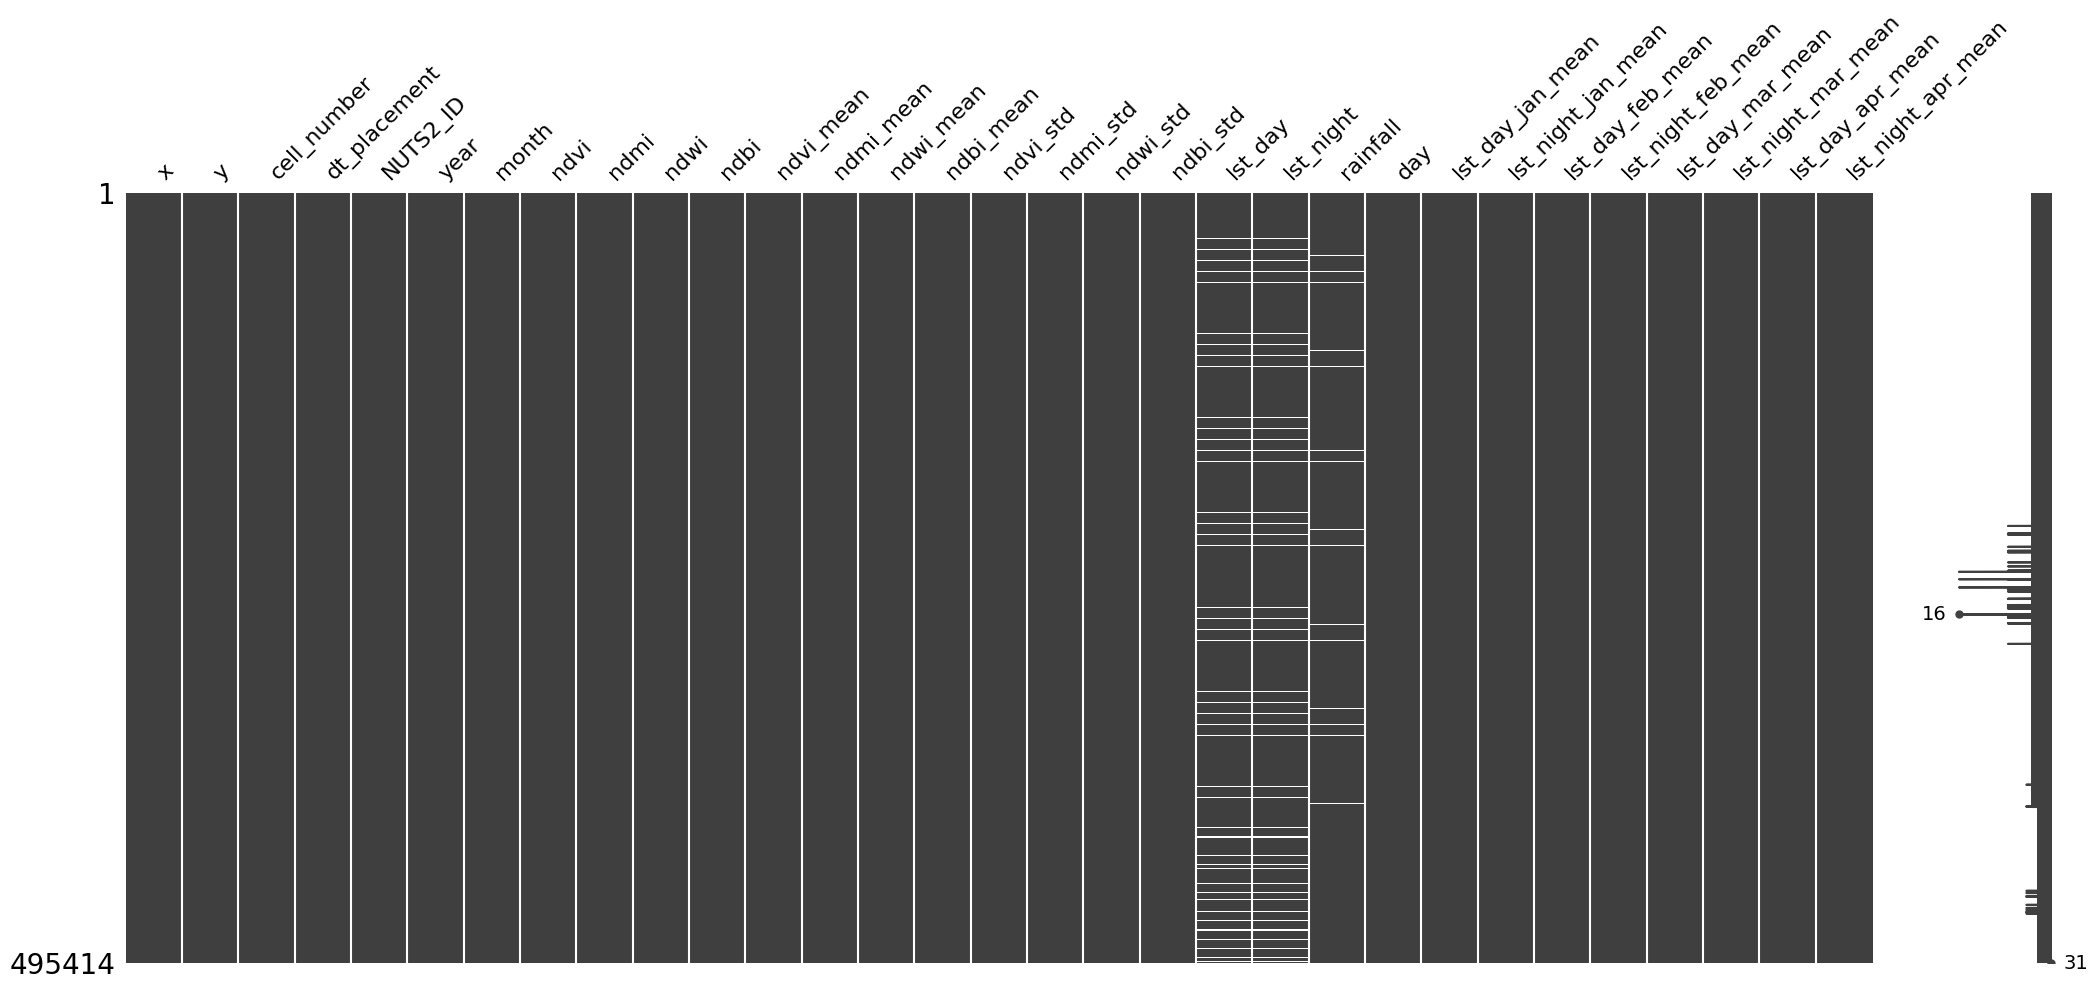

In [45]:
missingno.matrix(data_mean)

In [46]:
data_mean.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled_mean.csv', encoding='utf-8')